In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset

df = pd.read_csv(
    r"C:\Users\91958\Desktop\Machine Learning\datasets\Position_Salaries.csv"
)

# Display the first five rows

df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 368.0+ bytes


In [4]:
# Statistical summary of numerical columns

df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [5]:
# Checking for missing values

df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [6]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10
Columns : 3


In [7]:
# Removing the Position column (if it exists)

if "Position" in df.columns:
    df = df.drop("Position", axis=1)

# Selecting independent and dependent variables

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("Features:")
print(X[:5])

print("\nTarget:")
print(y[:5])

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Features:
[[1]
 [2]
 [3]
 [4]
 [5]]

Target:
[ 45000  50000  60000  80000 110000]

Features Shape: (10, 1)
Target Shape: (10,)


In [8]:
# Feature Scaling

sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)

y = y.reshape(-1, 1)
y = sc_y.fit_transform(y)
y = y.ravel()

print("Feature Scaling Completed Successfully!")

print("\nScaled Features:")
print(X[:5])

print("\nScaled Target:")
print(y[:5])

Feature Scaling Completed Successfully!

Scaled Features:
[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]]

Scaled Target:
[-0.72004253 -0.70243757 -0.66722767 -0.59680786 -0.49117815]


In [9]:
# Splitting the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (8, 1)
Testing Features : (2, 1)
Training Labels : (8,)
Testing Labels : (2,)


In [10]:
# Training the Support Vector Regression model

model = SVR(
    kernel="rbf"
)

model.fit(X_train, y_train)

print("Support Vector Regression model trained successfully!")

Support Vector Regression model trained successfully!


In [11]:
# Predicting the test data

y_pred_scaled = model.predict(X_test)

# Converting scaled values back to original salary values

y_pred = sc_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
)

y_actual = sc_y.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predicted Salaries:")
print(y_pred.flatten())

Predicted Salaries:
[435922.22629664  69760.27239844]


In [12]:
# Comparing Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_actual.flatten(),
    "Predicted": y_pred.flatten()
})

comparison.head(10)

,Actual,Predicted
0,500000.0,435922.226297
1,50000.0,69760.272398


In [13]:


# Calculating Mean Absolute Error

mae = mean_absolute_error(
    y_actual,
    y_pred
)

print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 41919.02


In [14]:


# Calculating Mean Squared Error

mse = mean_squared_error(
    y_actual,
    y_pred
)

print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 2248214724.02


In [15]:


# Calculating Root Mean Squared Error

rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 47415.34


In [16]:


# Calculating R² Score

r2 = r2_score(
    y_actual,
    y_pred
)

print(f"R² Score: {r2:.4f}")

R² Score: 0.9556


In [17]:
# Predicting salary for a new position level

new_level = np.array([[6.5]])

new_level_scaled = sc_X.transform(new_level)

predicted_salary_scaled = model.predict(new_level_scaled)

predicted_salary = sc_y.inverse_transform(
    predicted_salary_scaled.reshape(-1,1)
)

print(f"Predicted Salary for Level 6.5: ₹{predicted_salary[0][0]:,.2f}")

Predicted Salary for Level 6.5: ₹192,210.96


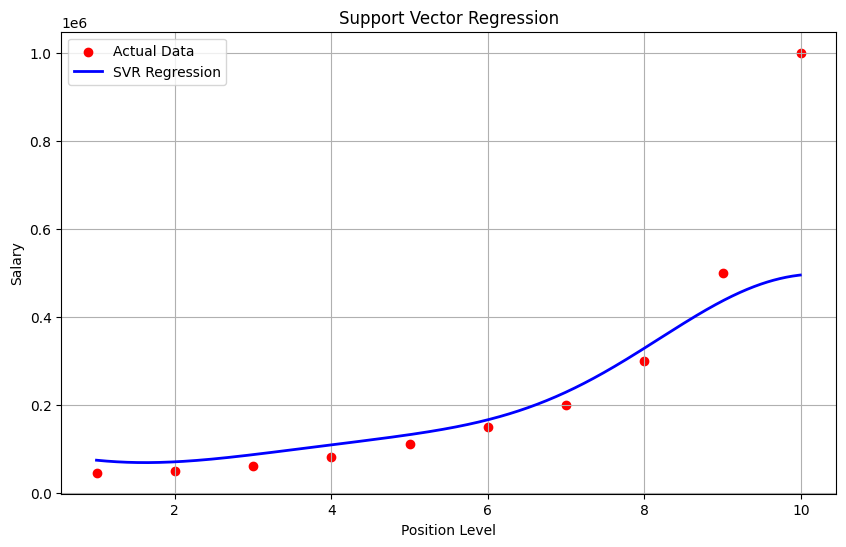

In [18]:
# Visualizing the SVR Regression results

X_grid = np.arange(
    min(sc_X.inverse_transform(X)),
    max(sc_X.inverse_transform(X)),
    0.01
)

X_grid = X_grid.reshape(-1,1)

X_grid_scaled = sc_X.transform(X_grid)

y_grid = model.predict(X_grid_scaled)

y_grid = sc_y.inverse_transform(
    y_grid.reshape(-1,1)
)

plt.figure(figsize=(10,6))

plt.scatter(
    sc_X.inverse_transform(X),
    sc_y.inverse_transform(y.reshape(-1,1)),
    color="red",
    label="Actual Data"
)

plt.plot(
    X_grid,
    y_grid,
    color="blue",
    linewidth=2,
    label="SVR Regression"
)

plt.title("Support Vector Regression")
plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Displaying SVR Hyperparameters

parameters = pd.DataFrame({
    "Hyperparameter": model.get_params().keys(),
    "Value": model.get_params().values()
})

display(parameters)

print("\nNumber of Support Vectors:")

print(model.support_vectors_.shape[0])

print("\nSupport Vectors:")

display(pd.DataFrame(
    sc_X.inverse_transform(model.support_vectors_),
    columns=["Level"]
))

,Hyperparameter,Value
0,C,1.0
1,cache_size,200
2,coef0,0.0
3,degree,3
4,epsilon,0.1
5,gamma,scale
6,kernel,rbf
7,max_iter,-1
8,shrinking,True
9,tol,0.001



Number of Support Vectors:
5

Support Vectors:


,Level
0,1.0
1,8.0
2,10.0
3,4.0
4,7.0


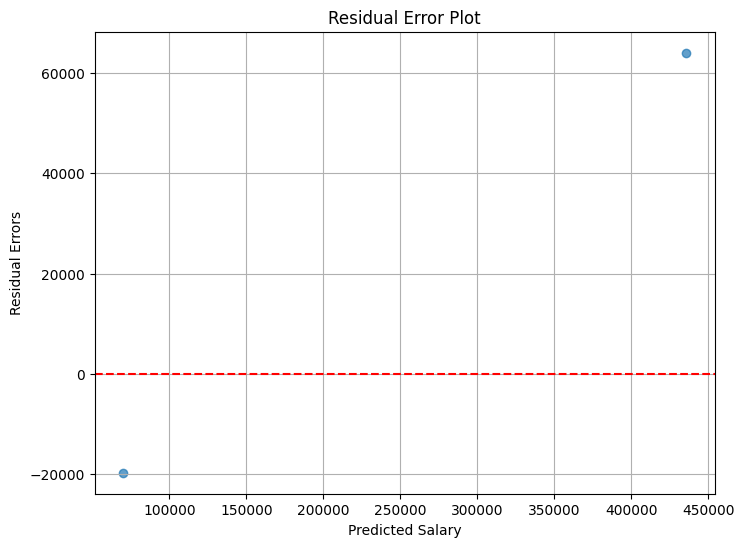

In [20]:
# Plotting Residual Errors

residuals = (
    y_actual.flatten() -
    y_pred.flatten()
)

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Error Plot")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual Errors")

plt.grid(True)

plt.show()